In [ ]:
# ============================================================
# 桌球自動發球機精準落點與四參數智慧控制模型
# 完整版本
#
# 第一階段：
# 四個參數 → 落點預測
#
# 第二階段：
# 目標落點 / 目標範圍
# → 四參數搜尋
# → 落點準確優先
# → 球路條件次要最佳化
# → 產生多組同落點、不同球路方案
# ============================================================

In [ ]:
# ============================================================
# 第 1 格：載入套件
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
import re
import heapq
from itertools import product

print("✅ 套件載入完成")

✅ 套件載入完成


In [ ]:
# ============================================================
# 第 2 格：上傳第一階段 / 後續實測 Excel
#
# 功能：
# 1. 可一次上傳 1 份或多份 Excel
# 2. 不限制檔案名稱
# 3. 自動排除非 Excel 檔案
# 4. 顯示每個 Excel 的工作表
# ============================================================

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("❌ 沒有上傳任何檔案")


# ------------------------------------------------------------
# 只保留 Excel 檔案
# ------------------------------------------------------------

excel_filenames = [
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith((".xlsx", ".xls"))
]


if len(excel_filenames) == 0:
    raise ValueError(
        "❌ 沒有找到 Excel 檔案。\n"
        "請上傳 .xlsx 或 .xls 檔案。"
    )


print("==========================================")
print("✅ Excel 上傳完成")
print("==========================================")

print(
    "Excel 檔案數量：",
    len(excel_filenames)
)


# ------------------------------------------------------------
# 顯示每個 Excel 的工作表
# ------------------------------------------------------------

excel_sheet_info = {}

for filename in excel_filenames:

    print("\n------------------------------------------")
    print("檔案：", filename)

    try:

        excel_file = pd.ExcelFile(filename)

        excel_sheet_info[filename] = (
            excel_file.sheet_names
        )

        print(
            "工作表：",
            excel_file.sheet_names
        )

    except Exception as e:

        excel_sheet_info[filename] = []

        print(
            "❌ 無法讀取 Excel：",
            str(e)
        )


print("\n==========================================")
print("✅ 檔案掃描完成")
print("下一格將自動尋找可用資料工作表")
print("==========================================")

Saving 第一階段補測_500組_LHS採樣_修改後.xlsx to 第一階段補測_500組_LHS採樣_修改後.xlsx
Saving 第一階段_1000組_LHS採樣_修改後.xlsx to 第一階段_1000組_LHS採樣_修改後.xlsx
✅ Excel 上傳完成
Excel 檔案數量： 2

------------------------------------------
檔案： 第一階段補測_500組_LHS採樣_修改後.xlsx
工作表： ['第二階段500組補測', '落點選項']

------------------------------------------
檔案： 第一階段_1000組_LHS採樣_修改後.xlsx
工作表： ['第一階段1000組', '工作表1', '說明']

✅ 檔案掃描完成
下一格將自動尋找可用資料工作表


In [ ]:
# ============================================================
# 第 3 格：自動讀取、驗證並合併所有實測資料
#
# 功能：
# 1. 不限制 Excel 檔名
# 2. 不限制工作表名稱
# 3. 自動尋找具有模型必要欄位的工作表
# 4. 每份資料逐一驗證
# 5. 有錯誤時標記：
#       - 哪個檔案
#       - 哪個工作表
#       - 缺少哪些欄位
#       - 發生什麼錯誤
# 6. 合法資料自動合併成 df
# 7. 保留資料來源
# 8. 自動建立跨檔案唯一的測試編號
# ============================================================


# ------------------------------------------------------------
# 模型匯入階段需要的必要欄位
#
# 這裡先定義一次，
# 第 4 格仍可繼續使用原本的欄位設定。
# ------------------------------------------------------------

import_required_columns = [
    "測試編號",
    "仰角角度",
    "左右位置",
    "旋球角度",
    "出球強度",
    "發球1_落點",
    "發球2_落點",
    "發球3_落點",
    "發球4_落點",
    "發球5_落點"
]


# ------------------------------------------------------------
# 儲存所有合法資料
# ------------------------------------------------------------

all_dataframes = []


# ------------------------------------------------------------
# 儲存匯入結果
#
# 後面會整理成 import_report
# ------------------------------------------------------------

import_records = []


print("==========================================")
print("開始檢查 Excel 資料")
print("==========================================")


# ============================================================
# 逐一處理每個 Excel
# ============================================================

for filename in excel_filenames:

    print("\n")
    print("==========================================")
    print("檢查檔案：", filename)
    print("==========================================")


    # --------------------------------------------------------
    # 嘗試開啟 Excel
    # --------------------------------------------------------

    try:

        excel_file = pd.ExcelFile(
            filename
        )

    except Exception as e:

        print(
            "❌ Excel 無法開啟：",
            str(e)
        )

        import_records.append({

            "檔案":
                filename,

            "工作表":
                None,

            "狀態":
                "❌ 檔案錯誤",

            "資料列數":
                0,

            "錯誤內容":
                str(e)
        })

        continue


    valid_sheet_found = False


    # ========================================================
    # 檢查這個 Excel 裡面的所有工作表
    # ========================================================

    for sheet_name in excel_file.sheet_names:

        print(
            f"\n🔍 檢查工作表：{sheet_name}"
        )


        try:

            # ------------------------------------------------
            # 讀取工作表
            # ------------------------------------------------

            temp_df = pd.read_excel(
                filename,
                sheet_name=sheet_name
            )


            # ------------------------------------------------
            # 清理欄位名稱
            # ------------------------------------------------

            temp_df.columns = (
                temp_df.columns
                .astype(str)
                .str.strip()
            )


            # ------------------------------------------------
            # 檢查是否完全空白
            # ------------------------------------------------

            if temp_df.empty:

                print(
                    "⚠️ 工作表沒有資料，跳過"
                )

                import_records.append({

                    "檔案":
                        filename,

                    "工作表":
                        sheet_name,

                    "狀態":
                        "⚠️ 空白工作表",

                    "資料列數":
                        0,

                    "錯誤內容":
                        "工作表沒有資料"
                })

                continue


            # ------------------------------------------------
            # 找出缺少的必要欄位
            # ------------------------------------------------

            missing_columns = [

                col

                for col
                in import_required_columns

                if col not in temp_df.columns
            ]


            # ------------------------------------------------
            # 欄位不完整
            # ------------------------------------------------

            if missing_columns:

                print(
                    "❌ 格式不符合模型資料格式"
                )

                print(
                    "缺少欄位：",
                    missing_columns
                )

                import_records.append({

                    "檔案":
                        filename,

                    "工作表":
                        sheet_name,

                    "狀態":
                        "❌ 欄位不完整",

                    "資料列數":
                        len(temp_df),

                    "錯誤內容":
                        "缺少欄位："
                        + ", ".join(
                            missing_columns
                        )
                })

                continue


            # =================================================
            # 到這裡代表：
            # 工作表具備模型需要的完整欄位
            # =================================================

            valid_sheet_found = True


            # ------------------------------------------------
            # 移除整列完全空白資料
            # ------------------------------------------------

            temp_df = (
                temp_df
                .dropna(
                    how="all"
                )
                .copy()
            )


            # ------------------------------------------------
            # 再次確認資料不是空的
            # ------------------------------------------------

            if temp_df.empty:

                print(
                    "⚠️ 欄位存在，但沒有實際資料"
                )

                import_records.append({

                    "檔案":
                        filename,

                    "工作表":
                        sheet_name,

                    "狀態":
                        "⚠️ 無實際資料",

                    "資料列數":
                        0,

                    "錯誤內容":
                        "欄位存在，但資料列為空"
                })

                continue


            # ------------------------------------------------
            # 保留原始測試編號
            #
            # 因為不同 Excel 可能都有：
            # 1、2、3、4...
            #
            # 若直接合併，後面的 GroupShuffleSplit
            # 會誤以為不同檔案中的 1 是同一組資料。
            # ------------------------------------------------

            temp_df[
                "原始測試編號"
            ] = temp_df[
                "測試編號"
            ]


            # ------------------------------------------------
            # 加入資料來源
            # ------------------------------------------------

            temp_df[
                "資料來源檔案"
            ] = filename

            temp_df[
                "資料來源工作表"
            ] = sheet_name


            # ------------------------------------------------
            # 建立全域唯一測試編號
            #
            # 格式：
            #
            # 檔案名稱 | 工作表 | 原始編號
            #
            # 例如：
            # 第一階段.xlsx|資料1|001
            #
            # 後面的 GroupShuffleSplit
            # 就不會把不同檔案誤認成同一組。
            # ------------------------------------------------

            temp_df[
                "測試編號"
            ] = (

                filename.astype(str)
                if isinstance(
                    filename,
                    pd.Series
                )
                else str(filename)

            )


            temp_df[
                "測試編號"
            ] = (

                str(filename)
                + "|"
                + str(sheet_name)
                + "|"
                + temp_df[
                    "原始測試編號"
                ]
                .astype(str)
            )


            # ------------------------------------------------
            # 加入總資料
            # ------------------------------------------------

            all_dataframes.append(
                temp_df
            )


            print(
                "✅ 工作表格式正確"
            )

            print(
                "可用資料列數：",
                len(temp_df)
            )


            import_records.append({

                "檔案":
                    filename,

                "工作表":
                    sheet_name,

                "狀態":
                    "✅ 成功匯入",

                "資料列數":
                    len(temp_df),

                "錯誤內容":
                    ""
            })


        # ====================================================
        # 工作表讀取發生其他錯誤
        # ====================================================

        except Exception as e:

            print(
                "❌ 工作表讀取錯誤：",
                str(e)
            )

            import_records.append({

                "檔案":
                    filename,

                "工作表":
                    sheet_name,

                "狀態":
                    "❌ 讀取錯誤",

                "資料列數":
                    0,

                "錯誤內容":
                    str(e)
            })


    # --------------------------------------------------------
    # 整個 Excel 都沒有可用工作表
    # --------------------------------------------------------

    if not valid_sheet_found:

        print(
            "\n⚠️ 此 Excel 沒有找到符合模型格式的工作表"
        )


# ============================================================
# 建立匯入報告
# ============================================================

import_report = pd.DataFrame(
    import_records
)


print("\n")
print("==========================================")
print("資料匯入檢查報告")
print("==========================================")

display(
    import_report
)


# ============================================================
# 若完全沒有合法資料，停止程式
# ============================================================

if len(all_dataframes) == 0:

    raise ValueError(
        "❌ 所有上傳檔案都沒有找到可用的模型資料。\n\n"
        "請查看上方『資料匯入檢查報告』確認錯誤位置。"
    )


# ============================================================
# 合併所有合法資料
# ============================================================

df = pd.concat(
    all_dataframes,
    ignore_index=True
)


# ============================================================
# 最終資訊
# ============================================================

successful_imports = (
    import_report[
        import_report["狀態"]
        ==
        "✅ 成功匯入"
    ]
)


failed_imports = (
    import_report[
        import_report["狀態"]
        !=
        "✅ 成功匯入"
    ]
)


print("\n")
print("==========================================")
print("✅ 所有合法資料合併完成")
print("==========================================")

print(
    "成功匯入工作表數量：",
    len(successful_imports)
)

print(
    "有警告 / 錯誤的工作表數量：",
    len(failed_imports)
)

print(
    "合併後資料大小：",
    df.shape
)

print(
    "合併後總資料列數：",
    len(df)
)

print(
    "資料來源檔案數：",
    df["資料來源檔案"].nunique()
)

print(
    "資料來源工作表數：",
    df[
        [
            "資料來源檔案",
            "資料來源工作表"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


print("\n欄位名稱：")

print(
    df.columns.tolist()
)


print("\n前 5 筆資料：")

display(
    df.head()
)

開始檢查 Excel 資料


檢查檔案： 第一階段補測_500組_LHS採樣_修改後.xlsx

🔍 檢查工作表：第二階段500組補測
✅ 工作表格式正確
可用資料列數： 500

🔍 檢查工作表：落點選項
❌ 格式不符合模型資料格式
缺少欄位： ['測試編號', '仰角角度', '左右位置', '旋球角度', '出球強度', '發球1_落點', '發球2_落點', '發球3_落點', '發球4_落點', '發球5_落點']


檢查檔案： 第一階段_1000組_LHS採樣_修改後.xlsx

🔍 檢查工作表：第一階段1000組
✅ 工作表格式正確
可用資料列數： 1000

🔍 檢查工作表：工作表1
⚠️ 工作表沒有資料，跳過

🔍 檢查工作表：說明
❌ 格式不符合模型資料格式
缺少欄位： ['測試編號', '仰角角度', '左右位置', '旋球角度', '出球強度', '發球1_落點', '發球2_落點', '發球3_落點', '發球4_落點', '發球5_落點']


資料匯入檢查報告


,檔案,工作表,狀態,資料列數,錯誤內容
0,第一階段補測_500組_LHS採樣_修改後.xlsx,第二階段500組補測,✅ 成功匯入,500,
1,第一階段補測_500組_LHS採樣_修改後.xlsx,落點選項,❌ 欄位不完整,29,"缺少欄位：測試編號, 仰角角度, 左右位置, 旋球角度, 出球強度, 發球1_落點, 發球2..."
2,第一階段_1000組_LHS採樣_修改後.xlsx,第一階段1000組,✅ 成功匯入,1000,
3,第一階段_1000組_LHS採樣_修改後.xlsx,工作表1,⚠️ 空白工作表,0,工作表沒有資料
4,第一階段_1000組_LHS採樣_修改後.xlsx,說明,❌ 欄位不完整,6,"缺少欄位：測試編號, 仰角角度, 左右位置, 旋球角度, 出球強度, 發球1_落點, 發球2..."




✅ 所有合法資料合併完成
成功匯入工作表數量： 2
有警告 / 錯誤的工作表數量： 3
合併後資料大小： (1500, 28)
合併後總資料列數： 1500
資料來源檔案數： 2
資料來源工作表數： 2

欄位名稱：
['測試編號', '仰角角度', '左右位置', '旋球角度', '出球強度', '發球1_落點', '發球2_落點', '發球3_落點', '發球4_落點', '發球5_落點', '原始測試編號', '資料來源檔案', '資料來源工作表', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', '(1,1)']

前 5 筆資料：


,測試編號,仰角角度,左右位置,旋球角度,出球強度,發球1_落點,發球2_落點,發球3_落點,發球4_落點,發球5_落點,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,"(1,1)"
0,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1001,28,4,1,24,"(3,3)","(3,2)","(3,3)","(3,3)","(3,3)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1002,28,4,59,12,"(2,3)","(2,3)","(2,3)","(2,3)","(2,3)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1003,15,7,3,82,"(3,4)","(3,4)","(3,4)","(3,4)","(3,4)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1004,2,3,49,40,"(4,1)","(4,2)","(4,1)","(4,2)","(4,2)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1005,28,6,59,36,"(4,4)","(4,4)","(4,4)","(4,4)","(4,4)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# 第 4 格：指定模型欄位
# ============================================================

feature_columns = [
    "仰角角度",
    "左右位置",
    "旋球角度",
    "出球強度"
]

shot_columns = [
    "發球1_落點",
    "發球2_落點",
    "發球3_落點",
    "發球4_落點",
    "發球5_落點"
]

id_column = "測試編號"

required_columns = (
    [id_column]
    + feature_columns
    + shot_columns
)

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        "❌ 缺少以下欄位：\n"
        + "\n".join(missing_columns)
    )

print("✅ 所有需要的欄位都存在")

✅ 所有需要的欄位都存在


In [ ]:
# ============================================================
# 第 5 格：四個參數合法性檢查
# ============================================================

parameter_limits = {
    "仰角角度": (1, 28),
    "左右位置": (1, 9),
    "旋球角度": (1, 59),  # Excel 欄位名；實際為球機旋球設定值 1~59（範圍涵蓋 360°）
    "出球強度": (1, 99)
}

for col, (min_value, max_value) in parameter_limits.items():

    # 轉數字
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    # 空值
    missing_count = df[col].isna().sum()

    # 超出設備範圍
    out_of_range = (
        (df[col] < min_value)
        |
        (df[col] > max_value)
    ).sum()

    # 非整數
    non_integer_count = (
        ~df[col].isna()
        &
        (df[col] % 1 != 0)
    ).sum()

    print(f"\n【{col}】")
    print("最小值 =", df[col].min())
    print("最大值 =", df[col].max())
    print("空白 =", missing_count)
    print("超出範圍 =", out_of_range)
    print("非整數 =", non_integer_count)

    if missing_count > 0:
        raise ValueError(
            f"❌ {col} 有空白資料"
        )

    if out_of_range > 0:
        raise ValueError(
            f"❌ {col} 有超出設備範圍的資料"
        )

    if non_integer_count > 0:
        raise ValueError(
            f"❌ {col} 有非整數資料"
        )

    df[col] = df[col].astype(int)

print("\n✅ 四個參數全部通過檢查")


【仰角角度】
最小值 = 1
最大值 = 28
空白 = 0
超出範圍 = 0
非整數 = 0

【左右位置】
最小值 = 1
最大值 = 9
空白 = 0
超出範圍 = 0
非整數 = 0

【旋球角度】
最小值 = 1
最大值 = 59
空白 = 0
超出範圍 = 0
非整數 = 0

【出球強度】
最小值 = 1
最大值 = 99
空白 = 0
超出範圍 = 0
非整數 = 0

✅ 四個參數全部通過檢查


In [ ]:
# ============================================================
# 第 6 格：建立落點類別
# ============================================================

VALID_LABELS = [
    f"({x},{y})"
    for x in range(1, 6)
    for y in range(1, 6)
]

# 4 種無效
INVALID_LABELS = [
    "飛出台面",
    "未過網",
    "其他無效",
    "球碰網後沒有進入有效區"
]

# 總共 25 + 4 = 29 類
ALL_LABELS = (
    VALID_LABELS
    +
    INVALID_LABELS
)

print("有效落點數量：", len(VALID_LABELS))
print("無效類別數量：", len(INVALID_LABELS))
print("總類別數量：", len(ALL_LABELS))

有效落點數量： 25
無效類別數量： 4
總類別數量： 29


In [ ]:
# ============================================================
# 第 7 格：落點文字整理
# ============================================================

def clean_landing_point(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # 全形符號轉半形
    value = (
        value
        .replace("（", "(")
        .replace("）", ")")
        .replace("，", ",")
    )

    # 移除空白
    value = re.sub(
        r"\s+",
        "",
        value
    )

    # --------------------------------------------------------
    # 使用者確認：
    # 碰桌後彈出 = 其他無效
    # --------------------------------------------------------

    if value == "碰桌後彈出":
        return "其他無效"

    # --------------------------------------------------------
    # 四種無效
    # --------------------------------------------------------

    if value in INVALID_LABELS:
        return value

    # --------------------------------------------------------
    # 座標格式：
    #
    # (4,3)
    # 4,3
    # （4，3）
    # --------------------------------------------------------

    match = re.fullmatch(
        r"\(([1-5]),([1-5])\)|([1-5]),([1-5])",
        value
    )

    if match:

        if match.group(1) is not None:
            x = match.group(1)
            y = match.group(2)
        else:
            x = match.group(3)
            y = match.group(4)

        return f"({x},{y})"

    # --------------------------------------------------------
    # 無法辨識
    # --------------------------------------------------------

    return np.nan


# 整理 5 次發球
for col in shot_columns:

    df[col] = (
        df[col]
        .apply(clean_landing_point)
    )

print("✅ 落點整理完成")

✅ 落點整理完成


In [ ]:
# ============================================================
# 第 8 格：寬資料 → 長資料
# ============================================================

long_df = df.melt(
    id_vars=[
        id_column,
        *feature_columns
    ],
    value_vars=shot_columns,
    var_name="發球次數",
    value_name="落點"
)

print("✅ 5 次發球已拆開")
print("資料筆數：", len(long_df))

display(
    long_df.head(15)
)

✅ 5 次發球已拆開
資料筆數： 7500


,測試編號,仰角角度,左右位置,旋球角度,出球強度,發球次數,落點
0,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1001,28,4,1,24,發球1_落點,"(3,3)"
1,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1002,28,4,59,12,發球1_落點,"(2,3)"
2,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1003,15,7,3,82,發球1_落點,"(3,4)"
3,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1004,2,3,49,40,發球1_落點,"(4,1)"
4,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1005,28,6,59,36,發球1_落點,"(4,4)"
5,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1006,23,5,59,36,發球1_落點,"(2,3)"
6,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1007,10,5,59,30,發球1_落點,"(4,3)"
7,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1008,5,6,11,34,發球1_落點,"(4,4)"
8,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1009,28,5,31,36,發球1_落點,飛出台面
9,第一階段補測_500組_LHS採樣_修改後.xlsx|第二階段500組補測|T1010,11,2,43,24,發球1_落點,"(4,2)"


In [ ]:
# ============================================================
# 第 9 格：檢查空白落點
# ============================================================

blank_mask = long_df["落點"].isna()

blank_count = blank_mask.sum()

print(
    "空白落點數量：",
    blank_count
)

if blank_count > 0:

    print("\n以下資料沒有落點：")

    display(
        long_df.loc[
            blank_mask,
            [
                id_column,
                *feature_columns,
                "發球次數",
                "落點"
            ]
        ]
    )

    print(
        "\n⚠️ 沒有實測結果的球不會拿來訓練。"
    )

# 移除沒有結果的球
long_df = (
    long_df
    .dropna(
        subset=["落點"]
    )
    .copy()
)

print("\n✅ 清理完成")
print("剩餘可用球數：", len(long_df))

空白落點數量： 1

以下資料沒有落點：


,測試編號,仰角角度,左右位置,旋球角度,出球強度,發球次數,落點
681,第一階段_1000組_LHS採樣_修改後.xlsx|第一階段1000組|T0182,5,8,21,8,發球1_落點,NaN



⚠️ 沒有實測結果的球不會拿來訓練。

✅ 清理完成
剩餘可用球數： 7499


In [ ]:
# ============================================================
# 第 10 格：檢查 29 類結果
# ============================================================

actual_labels = sorted(
    long_df["落點"]
    .unique()
    .tolist()
)

print(
    "實際出現的類別數量：",
    len(actual_labels)
)

print("\n實際類別：")

for label in actual_labels:
    print(label)

print(
    "\n預期總類別數量：",
    len(ALL_LABELS)
)

unknown_labels = [
    label
    for label in actual_labels
    if label not in ALL_LABELS
]

if unknown_labels:

    print("\n❌ 發現未知標籤：")

    for label in unknown_labels:
        print(label)

    raise ValueError(
        "請檢查 Excel 中的落點文字格式。"
    )

print("\n✅ 所有結果都符合 29 類設定")

實際出現的類別數量： 29

實際類別：
(1,1)
(1,2)
(1,3)
(1,4)
(1,5)
(2,1)
(2,2)
(2,3)
(2,4)
(2,5)
(3,1)
(3,2)
(3,3)
(3,4)
(3,5)
(4,1)
(4,2)
(4,3)
(4,4)
(4,5)
(5,1)
(5,2)
(5,3)
(5,4)
(5,5)
其他無效
未過網
球碰網後沒有進入有效區
飛出台面

預期總類別數量： 29

✅ 所有結果都符合 29 類設定


In [ ]:
# ============================================================
# 第 11 格：查看落點分布
# ============================================================

class_counts = (
    long_df["落點"]
    .value_counts()
    .reindex(
        ALL_LABELS,
        fill_value=0
    )
)

distribution_df = pd.DataFrame({
    "落點": class_counts.index,
    "球數": class_counts.values
})

distribution_df["比例"] = (
    distribution_df["球數"]
    /
    distribution_df["球數"].sum()
    *
    100
).round(2)

display(
    distribution_df
)

print(
    "\n總球數：",
    distribution_df["球數"].sum()
)

,落點,球數,比例
0,"(1,1)",18,0.24
1,"(1,2)",35,0.47
2,"(1,3)",27,0.36
3,"(1,4)",45,0.60
4,"(1,5)",21,0.28
5,"(2,1)",113,1.51
6,"(2,2)",204,2.72
7,"(2,3)",232,3.09
8,"(2,4)",179,2.39
9,"(2,5)",139,1.85



總球數： 7499


In [ ]:
# ============================================================
# 第 12 格：建立 X / y / groups
# ============================================================

X = long_df[
    feature_columns
].copy()

y = long_df[
    "落點"
].copy()

groups = long_df[
    id_column
].copy()

print("X 大小：", X.shape)
print("y 大小：", y.shape)
print(
    "Group 數量：",
    groups.nunique()
)

print("\nX：")
display(
    X.head()
)

print("\ny：")
display(
    y.head()
)

X 大小： (7499, 4)
y 大小： (7499,)
Group 數量： 1500

X：


,仰角角度,左右位置,旋球角度,出球強度
0,28,4,1,24
1,28,4,59,12
2,15,7,3,82
3,2,3,49,40
4,28,6,59,36



y：


,落點
0,"(3,3)"
1,"(2,3)"
2,"(3,4)"
3,"(4,1)"
4,"(4,4)"


In [ ]:
# ============================================================
# 第 13 格：Group Train / Test Split
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[
    train_idx
].copy()

X_test = X.iloc[
    test_idx
].copy()

y_train = y.iloc[
    train_idx
].copy()

y_test = y.iloc[
    test_idx
].copy()

groups_train = groups.iloc[
    train_idx
]

groups_test = groups.iloc[
    test_idx
]

print("========== Training ==========")
print(
    "球數：",
    len(X_train)
)

print(
    "參數組數：",
    groups_train.nunique()
)

print("\n========== Testing ==========")
print(
    "球數：",
    len(X_test)
)

print(
    "參數組數：",
    groups_test.nunique()
)

# ------------------------------------------------------------
# 確認沒有 Group 重疊
# ------------------------------------------------------------

overlap = (
    set(groups_train.unique())
    &
    set(groups_test.unique())
)

print(
    "\nTrain/Test Group 重疊數量：",
    len(overlap)
)

if len(overlap) > 0:

    raise ValueError(
        "❌ 發生資料洩漏：Train/Test 有相同測試編號！"
    )

print(
    "✅ Train/Test 沒有 Group 重疊"
)

========== Training ==========
球數： 5999
參數組數： 1200

========== Testing ==========
球數： 1500
參數組數： 300

Train/Test Group 重疊數量： 0
✅ Train/Test 沒有 Group 重疊


In [ ]:
# ============================================================
# 第 14 格：Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "✅ Random Forest 訓練完成"
)

✅ Random Forest 訓練完成


In [ ]:
# ============================================================
# 第 15 格：Extra Trees
# ============================================================

et_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_model.fit(
    X_train,
    y_train
)

print(
    "✅ Extra Trees 訓練完成"
)

✅ Extra Trees 訓練完成


In [ ]:
# ============================================================
# 第 16 格：模型比較
# ============================================================

rf_pred = rf_model.predict(
    X_test
)

et_pred = et_model.predict(
    X_test
)

results = []

for model_name, pred in [
    ("Random Forest", rf_pred),
    ("Extra Trees", et_pred)
]:

    results.append({

        "模型": model_name,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_test,
                pred
            ),

        "Macro F1":
            f1_score(
                y_test,
                pred,
                average="macro"
            ),

        "Weighted F1":
            f1_score(
                y_test,
                pred,
                average="weighted"
            )
    })

model_comparison = (
    pd.DataFrame(results)
)

display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

,模型,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Random Forest,0.4233,0.2440,0.2294,0.4211
1,Extra Trees,0.4100,0.2057,0.1930,0.4066


In [ ]:
# ============================================================
# 第 17 格：選擇最佳模型
# ============================================================

best_row = model_comparison.loc[
    model_comparison["Macro F1"].idxmax()
]

best_model_name = (
    best_row["模型"]
)

if best_model_name == "Random Forest":

    best_model = rf_model

    best_pred = rf_pred

else:

    best_model = et_model

    best_pred = et_pred

print("================================")
print(
    "最佳模型：",
    best_model_name
)
print("================================")

print(
    f"Accuracy          = "
    f"{best_row['Accuracy']:.4f}"
)

print(
    f"Balanced Accuracy = "
    f"{best_row['Balanced Accuracy']:.4f}"
)

print(
    f"Macro F1          = "
    f"{best_row['Macro F1']:.4f}"
)

print(
    f"Weighted F1       = "
    f"{best_row['Weighted F1']:.4f}"
)

最佳模型： Random Forest
Accuracy          = 0.4233
Balanced Accuracy = 0.2440
Macro F1          = 0.2294
Weighted F1       = 0.4211


In [ ]:
# ============================================================
# 第 18 格：Classification Report
# ============================================================

print(
    classification_report(
        y_test,
        best_pred,
        labels=ALL_LABELS,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       (1,1)       0.00      0.00      0.00         5
       (1,2)       0.00      0.00      0.00        12
       (1,3)       0.00      0.00      0.00         5
       (1,4)       0.00      0.00      0.00         4
       (1,5)       0.00      0.00      0.00         7
       (2,1)       0.60      0.29      0.39        21
       (2,2)       0.15      0.11      0.13        53
       (2,3)       0.22      0.24      0.23        46
       (2,4)       0.00      0.00      0.00        34
       (2,5)       0.28      0.17      0.22        40
       (3,1)       0.11      0.28      0.16        18
       (3,2)       0.08      0.03      0.05        58
       (3,3)       0.26      0.25      0.25        53
       (3,4)       0.33      0.39      0.36        72
       (3,5)       0.19      0.30      0.23        47
       (4,1)       0.35      0.41      0.38        17
       (4,2)       0.07      0.10      0.08        51
       (4,3)       0.37    

/tmp/ipykernel_3536/2920923145.py:42: UserWarning: Glyph 39131 (\N{CJK UNIFIED IDEOGRAPH-98DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3536/2920923145.py:42: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3536/2920923145.py:42: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3536/2920923145.py:42: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3536/2920923145.py:42: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3536/2920923145.py:42: UserWarning: Glyph 36942 (\N{CJK UNIFIED IDEOGRAPH-904E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3536/2920923145.py:42: UserWarning: Glyph 32178 (\N{CJK UNIFIED IDEOGRAPH-7DB2}

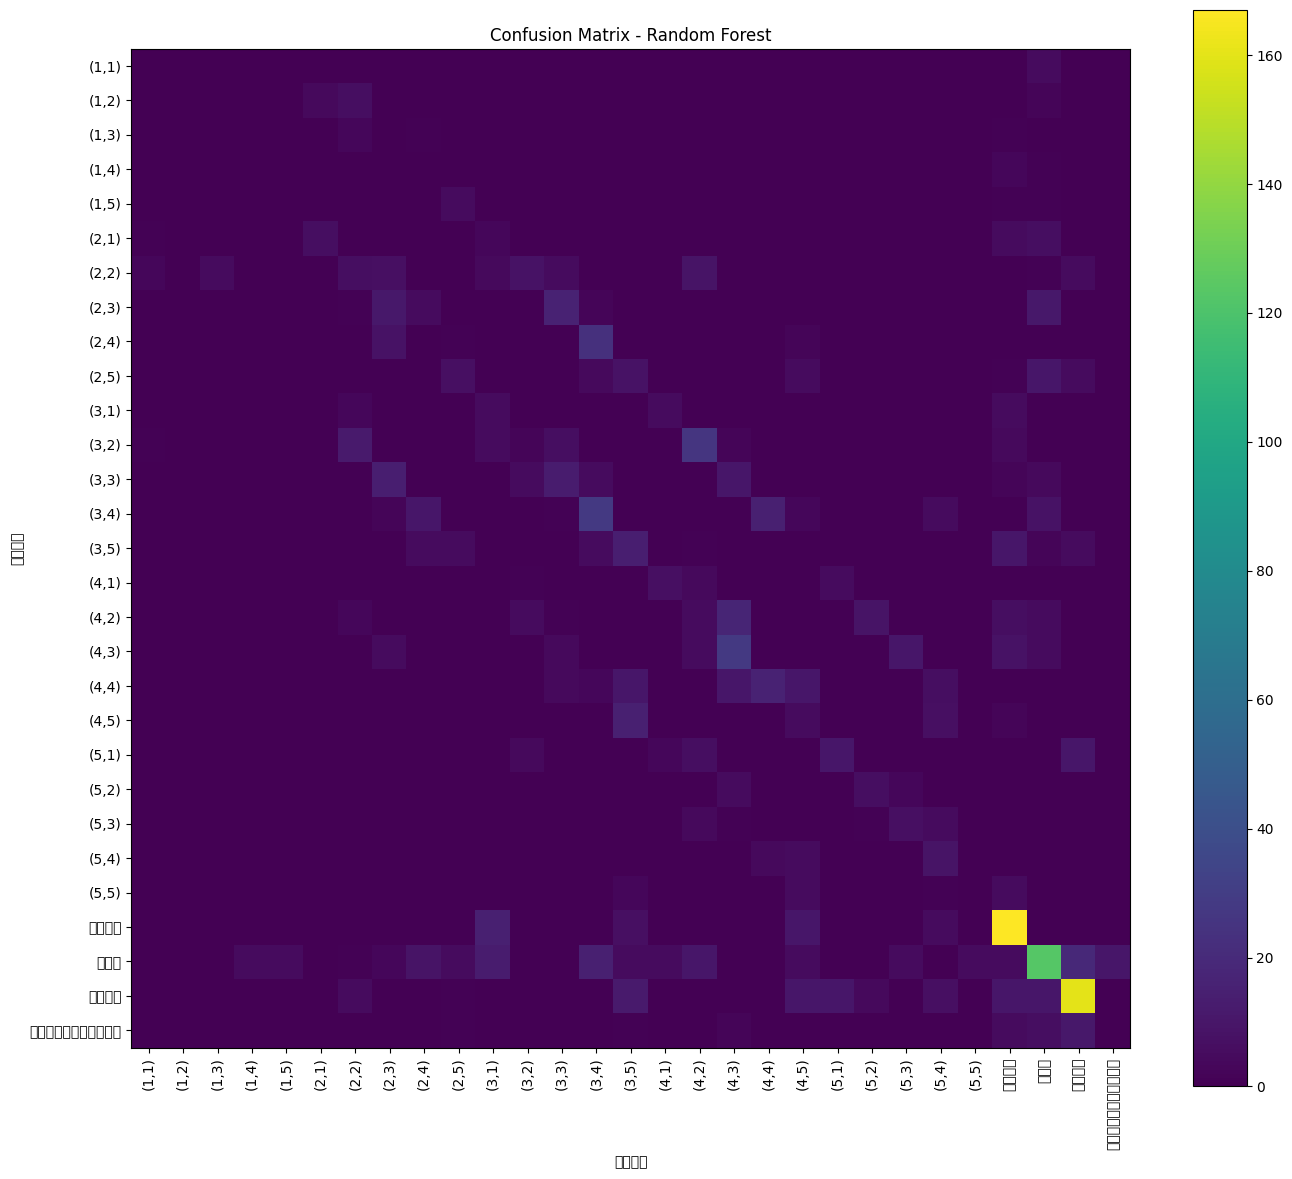

In [ ]:
# ============================================================
# 第 19 格：Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=ALL_LABELS
)

plt.figure(
    figsize=(14, 12)
)

plt.imshow(cm)

plt.xticks(
    range(len(ALL_LABELS)),
    ALL_LABELS,
    rotation=90
)

plt.yticks(
    range(len(ALL_LABELS)),
    ALL_LABELS
)

plt.xlabel(
    "模型預測"
)

plt.ylabel(
    "實際結果"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 第 20 格：落點空間距離
# ============================================================

def parse_coordinate(label):

    if not isinstance(
        label,
        str
    ):
        return None

    match = re.fullmatch(
        r"\(([1-5]),([1-5])\)",
        label
    )

    if not match:
        return None

    return (
        int(match.group(1)),
        int(match.group(2))
    )


spatial_records = []

for actual, pred in zip(
    y_test,
    best_pred
):

    actual_xy = parse_coordinate(
        actual
    )

    pred_xy = parse_coordinate(
        pred
    )

    if (
        actual_xy is not None
        and
        pred_xy is not None
    ):

        dx = (
            actual_xy[0]
            -
            pred_xy[0]
        )

        dy = (
            actual_xy[1]
            -
            pred_xy[1]
        )

        manhattan = (
            abs(dx)
            +
            abs(dy)
        )

        euclidean = np.sqrt(
            dx**2 + dy**2
        )

        spatial_records.append({

            "實際":
                actual,

            "預測":
                pred,

            "Manhattan":
                manhattan,

            "Euclidean":
                euclidean
        })


spatial_df = pd.DataFrame(
    spatial_records
)

if len(spatial_df) > 0:

    print(
        "有效座標預測筆數：",
        len(spatial_df)
    )

    print(
        "平均 Manhattan Distance：",
        round(
            spatial_df["Manhattan"].mean(),
            4
        )
    )

    print(
        "平均 Euclidean Distance：",
        round(
            spatial_df["Euclidean"].mean(),
            4
        )
    )

    print(
        "預測完全正確比例：",
        round(
            (
                spatial_df["Manhattan"]
                ==
                0
            ).mean(),
            4
        )
    )

    print(
        "預測差 1 格以內比例：",
        round(
            (
                spatial_df["Manhattan"]
                <=
                1
            ).mean(),
            4
        )
    )

else:

    print(
        "⚠️ 沒有足夠的有效座標資料可以計算空間距離。"
    )

有效座標預測筆數： 654
平均 Manhattan Distance： 0.9251
平均 Euclidean Distance： 0.8359
預測完全正確比例： 0.2829
預測差 1 格以內比例： 0.8058


In [ ]:
# ============================================================
# 第 21 格：Feature Importance
# ============================================================

importance_df = pd.DataFrame({

    "參數":
        feature_columns,

    "重要程度":
        best_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "重要程度",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_df
)

,參數,重要程度
0,出球強度,0.294412
1,旋球角度,0.278204
2,仰角角度,0.268156
3,左右位置,0.159228


In [ ]:
# ============================================================
# 第 22 格：建立一些共用函數
# ============================================================

# ------------------------------------------------------------
# 模型類別 → index
# ------------------------------------------------------------

class_to_index = {
    cls: i
    for i, cls
    in enumerate(
        best_model.classes_
    )
}

print(
    "模型目前實際學到的類別數：",
    len(best_model.classes_)
)

missing_model_classes = [
    label
    for label in ALL_LABELS
    if label not in class_to_index
]

if missing_model_classes:

    print(
        "\n⚠️ 下列類別在 Training 中沒有出現，"
        "因此模型目前無法直接預測這些類別："
    )

    for label in missing_model_classes:
        print(label)

else:

    print(
        "✅ 29 類全部存在於模型中"
    )


# ------------------------------------------------------------
# 無效機率
# ------------------------------------------------------------

def calculate_invalid_probability(
    probabilities
):

    invalid_prob = np.zeros(
        len(probabilities)
    )

    for invalid_label in INVALID_LABELS:

        if invalid_label in class_to_index:

            invalid_index = (
                class_to_index[
                    invalid_label
                ]
            )

            invalid_prob += (
                probabilities[
                    :,
                    invalid_index
                ]
            )

    return invalid_prob


# ------------------------------------------------------------
# 目標標籤整理
# ------------------------------------------------------------

def normalize_target_labels(
    target_landing
):

    # 單一座標
    if isinstance(
        target_landing,
        str
    ):

        labels = [
            target_landing
        ]

    # 多個座標
    elif isinstance(
        target_landing,
        (list, tuple, set)
    ):

        labels = list(
            target_landing
        )

    else:

        raise ValueError(
            "target_landing 必須是 "
            "例如 '(4,3)' 或 ['(4,3)', '(4,4)']"
        )

    normalized = []

    for label in labels:

        cleaned = clean_landing_point(
            label
        )

        if (
            pd.isna(cleaned)
            or
            cleaned not in VALID_LABELS
        ):

            raise ValueError(
                f"無效目標落點：{label}\n"
                f"必須是 (1,1)~(5,5)"
            )

        normalized.append(
            cleaned
        )

    return list(
        dict.fromkeys(normalized)
    )


# ------------------------------------------------------------
# 找座標到目標範圍的最小 Manhattan Distance
# ------------------------------------------------------------

def distance_to_targets(
    predicted_label,
    target_labels
):

    pred_xy = parse_coordinate(
        predicted_label
    )

    if pred_xy is None:
        return np.inf

    distances = []

    for target in target_labels:

        target_xy = parse_coordinate(
            target
        )

        if target_xy is None:
            continue

        dx = (
            pred_xy[0]
            -
            target_xy[0]
        )

        dy = (
            pred_xy[1]
            -
            target_xy[1]
        )

        distances.append(
            abs(dx) + abs(dy)
        )

    if not distances:
        return np.inf

    return min(distances)


# ------------------------------------------------------------
# 球路條件
#
# 重要修正：
# 「旋球角度」是 Excel 原始欄位名稱，為了相容既有資料保留。
# 但機器實際可調的是「旋球設定值 1~59」，不是 1~59 度。
# 說明書表示 1~59 的設定範圍涵蓋 360° 的旋轉方向。
# 因此本程式不再把數值越大解讀成「旋轉越強」。
# ------------------------------------------------------------

BALL_CONDITION_MAP = {

    "標準": [],

    "一般": [],

    "高速球": [
        ("出球強度", "max")
    ],

    "高強度": [
        ("出球強度", "max")
    ],

    "低速球": [
        ("出球強度", "min")
    ],

    "低強度": [
        ("出球強度", "min")
    ],

    # 旋轉方向不是「高 / 低旋轉」。
    # 使用者要指定球機的旋球設定值 1~59，
    # 模型會在落點合格的候選中，優先找最接近該設定值的方案。
    "旋轉方向": [
        ("旋球角度", "target_circular")
    ],

    "高仰角": [
        ("仰角角度", "max")
    ],

    "低仰角": [
        ("仰角角度", "min")
    ],

    "偏右": [
        ("左右位置", "max")
    ],

    "偏左": [
        ("左右位置", "min")
    ]
}


def normalize_ball_conditions(
    ball_condition
):

    if ball_condition is None:
        return ["標準"]

    if isinstance(
        ball_condition,
        str
    ):
        conditions = [
            ball_condition
        ]

    elif isinstance(
        ball_condition,
        (list, tuple, set)
    ):
        conditions = list(
            ball_condition
        )

    else:

        raise ValueError(
            "ball_condition 必須是字串或 list"
        )

    for condition in conditions:

        if condition not in BALL_CONDITION_MAP:

            raise ValueError(
                f"未知球路條件：{condition}\n"
                f"可使用："
                f"{list(BALL_CONDITION_MAP.keys())}"
            )

    return list(
        dict.fromkeys(conditions)
    )


# ------------------------------------------------------------
# 旋球設定值檢查
# ------------------------------------------------------------

def validate_spin_direction_value(
    spin_direction_value
):

    if spin_direction_value is None:
        raise ValueError(
            "使用『旋轉方向』時，必須指定 "
            "spin_direction_value=1~59。"
        )

    if pd.isna(spin_direction_value):
        raise ValueError(
            "spin_direction_value 不可以是空值"
        )

    if int(spin_direction_value) != spin_direction_value:
        raise ValueError(
            "spin_direction_value 必須是 1~59 的整數"
        )

    spin_direction_value = int(
        spin_direction_value
    )

    if not 1 <= spin_direction_value <= 59:
        raise ValueError(
            "spin_direction_value 必須在 1~59 之間"
        )

    return spin_direction_value


# ------------------------------------------------------------
# 旋球設定值的環狀距離
#
# 1~59 代表一整圈的離散設定位置。
# 因此 1 與 59 在循環方向上視為相鄰。
# 注意：這裡計算的是「設定值距離」，不是角度差。
# ------------------------------------------------------------

def circular_spin_setting_distance(
    spin_values,
    target_value
):

    target_value = validate_spin_direction_value(
        target_value
    )

    values = np.asarray(
        spin_values,
        dtype=float
    )

    direct_distance = np.abs(
        values - target_value
    )

    circular_distance = np.minimum(
        direct_distance,
        59 - direct_distance
    )

    return circular_distance


# ------------------------------------------------------------
# 將參數轉成 0~1
# ------------------------------------------------------------

def normalized_parameter_series(
    df_input
):

    result = pd.DataFrame(
        index=df_input.index
    )

    for col, (
        min_value,
        max_value
    ) in parameter_limits.items():

        result[col] = (
            df_input[col]
            -
            min_value
        ) / (
            max_value
            -
            min_value
        )

    return result.clip(
        0,
        1
    )


# ------------------------------------------------------------
# 計算球路條件分數
#
# 0 = 完全不符合
# 1 = 最符合
#
# 注意：
# 這個分數只用於「落點已經符合門檻」之後的第二階段排序。
# 不再讓球路條件與落點準確度混在同一層競爭。
# ------------------------------------------------------------

def calculate_condition_score(
    candidate_df,
    ball_condition,
    spin_direction_value=None
):

    conditions = normalize_ball_conditions(
        ball_condition
    )

    if "旋轉方向" in conditions:
        spin_direction_value = (
            validate_spin_direction_value(
                spin_direction_value
            )
        )

    norm_df = (
        normalized_parameter_series(
            candidate_df
        )
    )

    score_list = []

    for condition in conditions:

        rules = BALL_CONDITION_MAP[
            condition
        ]

        # 標準 / 一般
        if len(rules) == 0:

            score = pd.Series(
                0.5,
                index=candidate_df.index
            )

        else:

            rule_scores = []

            for col, direction in rules:

                if direction == "max":

                    rule_score = (
                        norm_df[col]
                    )

                elif direction == "min":

                    rule_score = (
                        1 - norm_df[col]
                    )

                elif direction == "target_circular":

                    distance = (
                        circular_spin_setting_distance(
                            candidate_df[col].to_numpy(),
                            spin_direction_value
                        )
                    )

                    # 59 個環狀位置的最大最短距離為 29。
                    rule_score = pd.Series(
                        1 - (distance / 29.0),
                        index=candidate_df.index
                    ).clip(
                        0,
                        1
                    )

                else:
                    raise ValueError(
                        f"未知方向：{direction}"
                    )

                rule_scores.append(
                    rule_score
                )

            score = sum(
                rule_scores
            ) / len(
                rule_scores
            )

        score_list.append(
            score
        )

    final_score = sum(
        score_list
    ) / len(
        score_list
    )

    return final_score


print(
    "✅ 共用函數建立完成"
)

模型目前實際學到的類別數： 29
✅ 29 類全部存在於模型中
✅ 共用函數建立完成


In [ ]:
# ============================================================
# 第 23 格：單組參數預測
# ============================================================

def validate_parameter_values(
    elevation,
    horizontal,
    spin_angle,
    power
):

    values = {

        "仰角角度":
            elevation,

        "左右位置":
            horizontal,

        "旋球角度":
            spin_angle,

        "出球強度":
            power
    }

    for col, value in values.items():

        min_value, max_value = (
            parameter_limits[col]
        )

        if pd.isna(value):

            raise ValueError(
                f"{col} 不可以是空值"
            )

        if (
            value < min_value
            or
            value > max_value
        ):

            raise ValueError(
                f"{col} 必須在 "
                f"{min_value}~{max_value} 之間"
            )

        if int(value) != value:

            raise ValueError(
                f"{col} 必須是整數"
            )

    return {
        "仰角角度":
            int(elevation),

        "左右位置":
            int(horizontal),

        "旋球角度":
            int(spin_angle),

        "出球強度":
            int(power)
    }


def predict_landing(
    elevation,
    horizontal,
    spin_angle,
    power,
    top_n=10
):

    values = validate_parameter_values(
        elevation,
        horizontal,
        spin_angle,
        power
    )

    input_df = pd.DataFrame(
        [values]
    )

    prediction = (
        best_model
        .predict(input_df)[0]
    )

    probabilities = (
        best_model
        .predict_proba(input_df)[0]
    )

    probability_df = pd.DataFrame({

        "落點":
            best_model.classes_,

        "預測機率":
            probabilities
    })

    probability_df = (
        probability_df
        .sort_values(
            "預測機率",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return (
        prediction,
        probability_df.head(top_n)
    )


# ------------------------------------------------------------
# 範例
# ------------------------------------------------------------

prediction, probability_df = (
    predict_landing(
        elevation=18,
        horizontal=5,
        spin_angle=30,
        power=65,
        top_n=10
    )
)

print(
    "\n模型預測結果：",
    prediction
)

print(
    "\n前 10 個最可能結果："
)

display(
    probability_df
)


模型預測結果： 飛出台面

前 10 個最可能結果：


,落點,預測機率
0,飛出台面,0.733794
1,"(4,3)",0.087796
2,"(5,4)",0.038351
3,"(3,4)",0.033703
4,未過網,0.027788
5,"(3,3)",0.022009
6,"(5,3)",0.017047
7,"(4,5)",0.015739
8,"(4,4)",0.008723
9,"(2,3)",0.008163


In [ ]:
# ============================================================
# 第 24 格：第一階段已測參數 Set
# ============================================================

tested_parameters = set(
    zip(
        df["仰角角度"],
        df["左右位置"],
        df["旋球角度"],
        df["出球強度"]
    )
)

print(
    "第一階段已測參數組合：",
    len(tested_parameters)
)

第一階段已測參數組合： 1500


In [ ]:
# ============================================================
# 第 25 格：
# 目標落點 → 搜尋四參數
#
# 修正後的最佳化原則：
#
# 第一階段：落點精準度是硬條件
#     ① 模型第一名預測必須落在目標
#     ② 目標落點機率必須達到門檻
#     ③ 無效球總機率必須低於門檻
#
# 第二階段：只有通過第一階段的候選
#           才依球路條件排序
#
# 例如：
#     高速球   → 合格候選中優先選出球強度高
#     低速球   → 合格候選中優先選出球強度低
#     旋轉方向 → 合格候選中優先選最接近指定 1~59 設定值
#
# 四個參數仍然全部一起搜尋：
#     仰角 1~28 × 左右 1~9 × 旋球 1~59 × 強度 1~99
#     = 1,471,932 組
# ============================================================


def filter_accurate_candidates(
    candidate_df,
    min_target_probability=0.60,
    max_invalid_probability=0.20
):

    if candidate_df.empty:
        return candidate_df.copy()

    accurate_mask = (
        (candidate_df["命中目標"] == 1)
        &
        (
            candidate_df["目標落點機率"]
            >= min_target_probability
        )
        &
        (
            candidate_df["無效總機率"]
            <= max_invalid_probability
        )
    )

    return (
        candidate_df.loc[
            accurate_mask
        ]
        .copy()
    )


# ------------------------------------------------------------
# 通過落點門檻後，再依球路條件排序
# ------------------------------------------------------------

def rank_candidate_dataframe(
    candidate_df,
    ball_condition="標準"
):

    if candidate_df.empty:
        return candidate_df.copy()

    conditions = normalize_ball_conditions(
        ball_condition
    )

    has_specific_route = any(
        condition not in ["標準", "一般"]
        for condition in conditions
    )

    if has_specific_route:

        # 落點已經先通過硬條件。
        # 第二階段讓球路條件真正成為主要排序依據。
        sort_columns = [
            "球路條件分數",
            "目標落點機率",
            "無效總機率",
            "目標距離_曼哈頓"
        ]

        ascending = [
            False,
            False,
            True,
            True
        ]

    else:

        # 標準 / 一般方案仍以落點精準度排序。
        sort_columns = [
            "目標落點機率",
            "無效總機率",
            "目標距離_曼哈頓"
        ]

        ascending = [
            False,
            True,
            True
        ]

    return (
        candidate_df
        .sort_values(
            by=sort_columns,
            ascending=ascending
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 若沒有任何候選通過硬門檻，
# 才使用這個 fallback 排序，避免完全沒有結果。
# ------------------------------------------------------------

def rank_fallback_candidates(
    candidate_df
):

    if candidate_df.empty:
        return candidate_df.copy()

    return (
        candidate_df
        .sort_values(
            by=[
                "命中目標",
                "目標落點機率",
                "無效總機率",
                "目標距離_曼哈頓",
                "球路條件分數"
            ],
            ascending=[
                False,
                False,
                True,
                True,
                False
            ]
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 建立一批候選的預測結果
# ------------------------------------------------------------

def build_candidate_result(
    batch_df,
    target_labels,
    conditions,
    spin_direction_value=None
):

    probabilities = (
        best_model
        .predict_proba(batch_df)
    )

    target_probability = np.zeros(
        len(batch_df)
    )

    for target_label in target_labels:

        target_index = (
            class_to_index[
                target_label
            ]
        )

        target_probability += (
            probabilities[
                :,
                target_index
            ]
        )

    best_index = np.argmax(
        probabilities,
        axis=1
    )

    predicted_labels = (
        best_model.classes_[
            best_index
        ]
    )

    hit_target = np.isin(
        predicted_labels,
        target_labels
    ).astype(int)

    invalid_probability = (
        calculate_invalid_probability(
            probabilities
        )
    )

    distances = np.array([
        distance_to_targets(
            pred,
            target_labels
        )
        for pred
        in predicted_labels
    ])

    condition_score = (
        calculate_condition_score(
            batch_df,
            conditions,
            spin_direction_value=spin_direction_value
        )
        .to_numpy()
    )

    batch_result = batch_df.copy()

    batch_result[
        "預測落點"
    ] = predicted_labels

    batch_result[
        "命中目標"
    ] = hit_target

    batch_result[
        "目標落點機率"
    ] = target_probability

    batch_result[
        "無效總機率"
    ] = invalid_probability

    batch_result[
        "目標距離_曼哈頓"
    ] = distances

    batch_result[
        "球路條件分數"
    ] = condition_score

    return batch_result



def search_best_parameters(
    target_landing,
    ball_condition="標準",
    top_n=20,
    chunk_size=50000,
    pool_size=None,
    min_target_probability=0.60,
    max_invalid_probability=0.20,
    spin_direction_value=None,
    exclude_tested_parameters=False
):

    target_labels = (
        normalize_target_labels(
            target_landing
        )
    )

    conditions = (
        normalize_ball_conditions(
            ball_condition
        )
    )

    if "旋轉方向" in conditions:
        spin_direction_value = (
            validate_spin_direction_value(
                spin_direction_value
            )
        )

    if not 0 <= min_target_probability <= 1:
        raise ValueError(
            "min_target_probability 必須在 0~1 之間"
        )

    if not 0 <= max_invalid_probability <= 1:
        raise ValueError(
            "max_invalid_probability 必須在 0~1 之間"
        )

    print("==========================================")
    print("開始搜尋最佳四參數")
    print("==========================================")

    print(
        "目標落點 / 範圍：",
        target_labels
    )

    print(
        "球路條件：",
        conditions
    )

    if "旋轉方向" in conditions:
        print(
            "指定旋球設定值：",
            spin_direction_value,
            "（1~59；不是角度）"
        )

    print(
        "落點機率門檻：",
        f"{min_target_probability * 100:.1f}%"
    )

    print(
        "無效球機率上限：",
        f"{max_invalid_probability * 100:.1f}%"
    )

    # --------------------------------------------------------
    # 檢查目標類別是否存在於模型
    # --------------------------------------------------------

    missing_targets = [
        label
        for label in target_labels
        if label not in class_to_index
    ]

    if missing_targets:

        raise ValueError(
            "目前模型沒有學到目標類別：\n"
            +
            "\n".join(missing_targets)
            +
            "\n\n請確認 Training 中有這些落點資料。"
        )

    # --------------------------------------------------------
    # 完整四維搜尋空間
    # --------------------------------------------------------

    elevations = range(1, 29)
    horizontals = range(1, 10)
    spins = range(1, 60)
    powers = range(1, 100)

    total_combinations = (
        len(elevations)
        *
        len(horizontals)
        *
        len(spins)
        *
        len(powers)
    )

    expected_total = (
        28 * 9 * 59 * 99
    )

    if total_combinations != expected_total:
        raise RuntimeError(
            "❌ 四參數搜尋空間計算錯誤"
        )

    print(
        "\n完整四參數搜尋空間："
    )
    print("仰角角度：1~28")
    print("左右位置：1~9")
    print("旋球設定值：1~59（涵蓋 360°；不是度數）")
    print("出球強度：1~99（說明書約 12~86 km/h）")

    print(
        "所有可能參數組合：",
        f"{total_combinations:,}"
    )

    if exclude_tested_parameters:
        print(
            "搜尋模式：探索模式，排除第一階段已測參數"
        )
    else:
        print(
            "搜尋模式：完整推薦模式，已測與未測參數全部納入"
        )

    if pool_size is None:
        pool_size = max(
            top_n * 20,
            200
        )

    # 通過落點硬條件的最佳候選
    current_accurate = pd.DataFrame()

    # 若完全沒有候選通過門檻，保留 fallback
    current_fallback = pd.DataFrame()

    batch = []
    processed = 0

    def process_batch(
        batch_values,
        current_accurate,
        current_fallback
    ):

        if len(batch_values) == 0:
            return current_accurate, current_fallback

        batch_df = pd.DataFrame(
            batch_values,
            columns=feature_columns
        )

        batch_result = build_candidate_result(
            batch_df=batch_df,
            target_labels=target_labels,
            conditions=conditions,
            spin_direction_value=spin_direction_value
        )

        # fallback 每批仍只保留最有希望的候選
        batch_fallback = (
            rank_fallback_candidates(
                batch_result
            )
            .head(pool_size)
        )

        current_fallback = pd.concat(
            [
                current_fallback,
                batch_fallback
            ],
            ignore_index=True
        )

        current_fallback = (
            rank_fallback_candidates(
                current_fallback
            )
            .head(pool_size)
            .copy()
        )

        # 第一階段：先做落點硬條件篩選
        accurate_batch = (
            filter_accurate_candidates(
                batch_result,
                min_target_probability=min_target_probability,
                max_invalid_probability=max_invalid_probability
            )
        )

        if not accurate_batch.empty:

            # 第二階段：合格後才依球路條件排序
            accurate_batch = (
                rank_candidate_dataframe(
                    accurate_batch,
                    ball_condition=conditions
                )
                .head(pool_size)
            )

            current_accurate = pd.concat(
                [
                    current_accurate,
                    accurate_batch
                ],
                ignore_index=True
            )

            current_accurate = (
                rank_candidate_dataframe(
                    current_accurate,
                    ball_condition=conditions
                )
                .head(pool_size)
                .copy()
            )

        return current_accurate, current_fallback

    # --------------------------------------------------------
    # 四個參數全部一起搜尋
    # --------------------------------------------------------

    for combination in product(
        elevations,
        horizontals,
        spins,
        powers
    ):

        if (
            exclude_tested_parameters
            and
            combination in tested_parameters
        ):
            continue

        batch.append(
            combination
        )

        if len(batch) < chunk_size:
            continue

        current_accurate, current_fallback = (
            process_batch(
                batch,
                current_accurate,
                current_fallback
            )
        )

        processed += len(batch)

        print(
            f"\r目前已搜尋：約 "
            f"{processed:,} 組候選",
            end=""
        )

        batch = []

    # 最後一批
    if len(batch) > 0:

        current_accurate, current_fallback = (
            process_batch(
                batch,
                current_accurate,
                current_fallback
            )
        )

        processed += len(batch)

    print(
        f"\n實際完成搜尋：{processed:,} 組"
    )

    # --------------------------------------------------------
    # 最終結果
    # --------------------------------------------------------

    if not current_accurate.empty:

        result_df = (
            rank_candidate_dataframe(
                current_accurate,
                ball_condition=conditions
            )
            .head(top_n)
            .copy()
        )

        search_status = "✅ 通過落點精準度門檻"

    else:

        result_df = (
            rank_fallback_candidates(
                current_fallback
            )
            .head(top_n)
            .copy()
        )

        search_status = (
            "⚠️ 沒有候選同時通過全部落點門檻，"
            "以下為最接近目標的 fallback 候選"
        )

    result_df.insert(
        0,
        "目標落點",
        " / ".join(target_labels)
    )

    result_df.insert(
        1,
        "球路條件",
        " + ".join(conditions)
    )

    if "旋轉方向" in conditions:
        result_df.insert(
            2,
            "指定旋球設定值",
            spin_direction_value
        )

    print("\n")
    print(search_status)
    print("✅ 參數搜尋完成")

    print(
        "\n前",
        top_n,
        "組推薦參數："
    )

    display(
        result_df
    )

    return result_df

In [ ]:
# ============================================================
# 第 26 格：測試
#
# 這次不是單純找「最高機率」，
# 而是：
#
# ① 先看預測結果是否命中目標
# ② 再看目標機率
# ③ 再看無效機率
# ④ 再看球路條件
# ============================================================

best_parameters = search_best_parameters(
    target_landing="(4,3)",
    ball_condition="標準",
    top_n=20,
    chunk_size=50000
)

display(
    best_parameters
)

開始搜尋最佳四參數
目標落點 / 範圍： ['(4,3)']
球路條件： ['標準']
落點機率門檻： 60.0%
無效球機率上限： 20.0%

完整四參數搜尋空間：
仰角角度：1~28
左右位置：1~9
旋球設定值：1~59（涵蓋 360°；不是度數）
出球強度：1~99（說明書約 12~86 km/h）
所有可能參數組合： 1,471,932
搜尋模式：完整推薦模式，已測與未測參數全部納入
目前已搜尋：約 1,450,000 組候選
實際完成搜尋：1,471,932 組


✅ 通過落點精準度門檻
✅ 參數搜尋完成

前 20 組推薦參數：


,目標落點,球路條件,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",標準,23,5,6,49,"(4,3)",1,0.978422,0.012618,0.0,0.5
1,"(4,3)",標準,20,4,53,54,"(4,3)",1,0.971967,0.012168,0.0,0.5
2,"(4,3)",標準,4,5,53,36,"(4,3)",1,0.971710,0.000244,0.0,0.5
3,"(4,3)",標準,9,4,57,40,"(4,3)",1,0.967632,0.008176,0.0,0.5
4,"(4,3)",標準,9,4,58,40,"(4,3)",1,0.967632,0.008176,0.0,0.5
5,"(4,3)",標準,26,4,59,40,"(4,3)",1,0.963932,0.005768,0.0,0.5
6,"(4,3)",標準,6,5,59,30,"(4,3)",1,0.963555,0.000305,0.0,0.5
7,"(4,3)",標準,15,4,5,12,"(4,3)",1,0.962392,0.008780,0.0,0.5
8,"(4,3)",標準,28,5,1,40,"(4,3)",1,0.961984,0.004579,0.0,0.5
9,"(4,3)",標準,26,5,27,26,"(4,3)",1,0.961936,0.002931,0.0,0.5


,目標落點,球路條件,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",標準,23,5,6,49,"(4,3)",1,0.978422,0.012618,0.0,0.5
1,"(4,3)",標準,20,4,53,54,"(4,3)",1,0.971967,0.012168,0.0,0.5
2,"(4,3)",標準,4,5,53,36,"(4,3)",1,0.971710,0.000244,0.0,0.5
3,"(4,3)",標準,9,4,57,40,"(4,3)",1,0.967632,0.008176,0.0,0.5
4,"(4,3)",標準,9,4,58,40,"(4,3)",1,0.967632,0.008176,0.0,0.5
5,"(4,3)",標準,26,4,59,40,"(4,3)",1,0.963932,0.005768,0.0,0.5
6,"(4,3)",標準,6,5,59,30,"(4,3)",1,0.963555,0.000305,0.0,0.5
7,"(4,3)",標準,15,4,5,12,"(4,3)",1,0.962392,0.008780,0.0,0.5
8,"(4,3)",標準,28,5,1,40,"(4,3)",1,0.961984,0.004579,0.0,0.5
9,"(4,3)",標準,26,5,27,26,"(4,3)",1,0.961936,0.002931,0.0,0.5


In [ ]:
# ============================================================
# 第 27 格：
# 多種球路方案
#
# 同一個目標落點可以要求：
#     ① 高速球
#     ② 低速球
#     ③ 指定旋轉方向（用球機 1~59 設定值表示）
#
# 注意：
# 「旋轉方向」不是高旋轉。
# 1~59 是球機設定值，說明書表示其範圍涵蓋 360°，
# 但不能直接把 1~59 當成角度或旋轉強度。
# ============================================================

# 例如：
#
# 高速球：
#
# high_speed_result = search_best_parameters(
#     target_landing="(4,3)",
#     ball_condition="高速球",
#     top_n=10,
#     min_target_probability=0.60,
#     max_invalid_probability=0.20
# )
#
#
# 指定旋轉方向（例：球機旋球設定值 30）：
#
# spin_direction_result = search_best_parameters(
#     target_landing="(4,3)",
#     ball_condition="旋轉方向",
#     spin_direction_value=30,
#     top_n=10,
#     min_target_probability=0.60,
#     max_invalid_probability=0.20
# )
#
#
# 低速球：
#
# low_speed_result = search_best_parameters(
#     target_landing="(4,3)",
#     ball_condition="低速球",
#     top_n=10,
#     min_target_probability=0.60,
#     max_invalid_probability=0.20
# )

In [ ]:
# ============================================================
# 第 28 格：
# 一次搜尋多種「同落點、不同球路」
#
# 只走一次完整的四參數搜尋空間，
# 同時保留不同球路條件各自的最佳候選。
#
# 同樣採用兩階段原則：
# ① 先通過落點精準度門檻
# ② 再依各自球路條件最佳化
# ============================================================


def search_multiple_route_conditions(
    target_landing,
    ball_conditions,
    top_n=5,
    chunk_size=50000,
    pool_size=200,
    min_target_probability=0.60,
    max_invalid_probability=0.20,
    spin_direction_value=None,
    exclude_tested_parameters=False
):

    target_labels = (
        normalize_target_labels(
            target_landing
        )
    )

    conditions = (
        normalize_ball_conditions(
            ball_conditions
        )
    )

    if "旋轉方向" in conditions:
        spin_direction_value = (
            validate_spin_direction_value(
                spin_direction_value
            )
        )

    print("==========================================")
    print("多球路方案搜尋")
    print("==========================================")

    print(
        "目標：",
        target_labels
    )

    print(
        "球路方案：",
        conditions
    )

    if "旋轉方向" in conditions:
        print(
            "指定旋球設定值：",
            spin_direction_value,
            "（1~59；不是角度）"
        )

    print(
        "落點機率門檻：",
        f"{min_target_probability * 100:.1f}%"
    )

    print(
        "無效球機率上限：",
        f"{max_invalid_probability * 100:.1f}%"
    )

    # --------------------------------------------------------
    # 確認目標存在
    # --------------------------------------------------------

    missing_targets = [
        label
        for label in target_labels
        if label not in class_to_index
    ]

    if missing_targets:

        raise ValueError(
            "以下目標類別不在模型中：\n"
            +
            "\n".join(missing_targets)
        )

    # 每一種球路都保留自己的「合格候選」與 fallback
    route_pools = {
        condition: pd.DataFrame()
        for condition in conditions
    }

    fallback_pools = {
        condition: pd.DataFrame()
        for condition in conditions
    }

    batch = []

    elevations = range(1, 29)
    horizontals = range(1, 10)
    spins = range(1, 60)
    powers = range(1, 100)

    total_combinations = (
        len(elevations)
        *
        len(horizontals)
        *
        len(spins)
        *
        len(powers)
    )

    expected_total = (
        28 * 9 * 59 * 99
    )

    if total_combinations != expected_total:
        raise RuntimeError(
            "❌ 四參數搜尋空間計算錯誤"
        )

    print(
        "完整四參數組合：",
        f"{total_combinations:,}"
    )

    if exclude_tested_parameters:
        print(
            "搜尋模式：探索模式，排除第一階段已測參數"
        )
    else:
        print(
            "搜尋模式：完整推薦模式，已測與未測參數全部納入"
        )

    processed = 0

    def process_multi_route_batch(
        batch_values
    ):

        if len(batch_values) == 0:
            return

        batch_df = pd.DataFrame(
            batch_values,
            columns=feature_columns
        )

        probabilities = (
            best_model
            .predict_proba(batch_df)
        )

        target_probability = np.zeros(
            len(batch_df)
        )

        for target_label in target_labels:

            target_probability += (
                probabilities[
                    :,
                    class_to_index[
                        target_label
                    ]
                ]
            )

        best_index = np.argmax(
            probabilities,
            axis=1
        )

        predicted_labels = (
            best_model.classes_[
                best_index
            ]
        )

        hit_target = np.isin(
            predicted_labels,
            target_labels
        ).astype(int)

        invalid_probability = (
            calculate_invalid_probability(
                probabilities
            )
        )

        distances = np.array([
            distance_to_targets(
                pred,
                target_labels
            )
            for pred
            in predicted_labels
        ])

        base_result = batch_df.copy()

        base_result[
            "預測落點"
        ] = predicted_labels

        base_result[
            "命中目標"
        ] = hit_target

        base_result[
            "目標落點機率"
        ] = target_probability

        base_result[
            "無效總機率"
        ] = invalid_probability

        base_result[
            "目標距離_曼哈頓"
        ] = distances

        for condition in conditions:

            condition_spin_value = (
                spin_direction_value
                if condition == "旋轉方向"
                else None
            )

            condition_score = (
                calculate_condition_score(
                    batch_df,
                    [condition],
                    spin_direction_value=condition_spin_value
                )
                .to_numpy()
            )

            route_result = (
                base_result.copy()
            )

            route_result[
                "球路條件分數"
            ] = condition_score

            # fallback pool
            fallback_result = (
                rank_fallback_candidates(
                    route_result
                )
                .head(pool_size)
            )

            fallback_pools[condition] = (
                pd.concat(
                    [
                        fallback_pools[condition],
                        fallback_result
                    ],
                    ignore_index=True
                )
            )

            fallback_pools[condition] = (
                rank_fallback_candidates(
                    fallback_pools[condition]
                )
                .head(pool_size)
                .copy()
            )

            # 第一階段：落點硬條件
            accurate_result = (
                filter_accurate_candidates(
                    route_result,
                    min_target_probability=min_target_probability,
                    max_invalid_probability=max_invalid_probability
                )
            )

            if accurate_result.empty:
                continue

            # 第二階段：球路最佳化
            accurate_result = (
                rank_candidate_dataframe(
                    accurate_result,
                    ball_condition=[condition]
                )
                .head(pool_size)
            )

            route_pools[condition] = (
                pd.concat(
                    [
                        route_pools[condition],
                        accurate_result
                    ],
                    ignore_index=True
                )
            )

            route_pools[condition] = (
                rank_candidate_dataframe(
                    route_pools[condition],
                    ball_condition=[condition]
                )
                .head(pool_size)
                .copy()
            )

    # --------------------------------------------------------
    # 四個參數全部一起搜尋
    # --------------------------------------------------------

    for combination in product(
        elevations,
        horizontals,
        spins,
        powers
    ):

        if (
            exclude_tested_parameters
            and
            combination in tested_parameters
        ):
            continue

        batch.append(
            combination
        )

        if len(batch) < chunk_size:
            continue

        process_multi_route_batch(
            batch
        )

        processed += len(batch)

        print(
            f"\r目前已搜尋約 "
            f"{processed:,} 組候選",
            end=""
        )

        batch = []

    if len(batch) > 0:

        process_multi_route_batch(
            batch
        )

        processed += len(batch)

    print(
        f"\n實際完成搜尋：{processed:,} 組"
    )

    # --------------------------------------------------------
    # 最後整理
    # --------------------------------------------------------

    final_results = {}

    for condition in conditions:

        if not route_pools[condition].empty:

            result = (
                rank_candidate_dataframe(
                    route_pools[condition],
                    ball_condition=[condition]
                )
                .head(top_n)
                .copy()
            )

            status = "✅ 通過落點精準度門檻"

        else:

            result = (
                rank_fallback_candidates(
                    fallback_pools[condition]
                )
                .head(top_n)
                .copy()
            )

            status = (
                "⚠️ 此球路沒有候選通過全部落點門檻，"
                "以下為 fallback 候選"
            )

        result.insert(
            0,
            "目標落點",
            " / ".join(target_labels)
        )

        result.insert(
            1,
            "球路條件",
            condition
        )

        if condition == "旋轉方向":
            result.insert(
                2,
                "指定旋球設定值",
                spin_direction_value
            )

        final_results[condition] = (
            result
        )

        print(
            f"\n\n========== {condition} =========="
        )
        print(status)

        display(
            result
        )

    print(
        "\n✅ 多球路搜尋完成"
    )

    return final_results

In [ ]:
# ============================================================
# 第 29 格：
# 一次產生同一落點的多種球路
#
# 範例：
# ① 高速球
# ② 指定旋轉方向
# ③ 低速球
#
# SPIN_DIRECTION_VALUE 是「球機旋球設定值 1~59」，
# 不是角度，也不是旋轉強度。
# 請依你實際想測試的旋轉方向設定值修改。
# ============================================================

SPIN_DIRECTION_VALUE = 30

multi_route_results = (
    search_multiple_route_conditions(
        target_landing="(4,3)",

        ball_conditions=[
            "高速球",
            "旋轉方向",
            "低速球"
        ],

        spin_direction_value=(
            SPIN_DIRECTION_VALUE
        ),

        top_n=5,

        chunk_size=50000,

        pool_size=200,

        min_target_probability=0.60,

        max_invalid_probability=0.20,

        # False = 正式推薦：1,471,932 組全部納入
        # True  = 探索模式：排除第一階段已測參數
        exclude_tested_parameters=False
    )
)

多球路方案搜尋
目標： ['(4,3)']
球路方案： ['高速球', '旋轉方向', '低速球']
指定旋球設定值： 30 （1~59；不是角度）
落點機率門檻： 60.0%
無效球機率上限： 20.0%
完整四參數組合： 1,471,932
搜尋模式：完整推薦模式，已測與未測參數全部納入
目前已搜尋約 1,450,000 組候選
實際完成搜尋：1,471,932 組


========== 高速球 ==========
✅ 通過落點精準度門檻


,目標落點,球路條件,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",高速球,17,4,7,85,"(4,3)",1,0.841081,0.102575,0.0,0.857143
1,"(4,3)",高速球,17,4,8,85,"(4,3)",1,0.801793,0.141440,0.0,0.857143
2,"(4,3)",高速球,17,4,6,85,"(4,3)",1,0.775704,0.141149,0.0,0.857143
3,"(4,3)",高速球,16,4,7,85,"(4,3)",1,0.663637,0.178469,0.0,0.857143
4,"(4,3)",高速球,17,4,5,85,"(4,3)",1,0.644838,0.180510,0.0,0.857143




========== 旋轉方向 ==========
✅ 通過落點精準度門檻


,目標落點,球路條件,指定旋球設定值,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",旋轉方向,30,9,5,30,26,"(4,3)",1,0.939153,0.011532,0.0,1.0
1,"(4,3)",旋轉方向,30,9,5,30,27,"(4,3)",1,0.922899,0.015532,0.0,1.0
2,"(4,3)",旋轉方向,30,10,5,30,26,"(4,3)",1,0.858019,0.023736,0.0,1.0
3,"(4,3)",旋轉方向,30,10,5,30,27,"(4,3)",1,0.844251,0.025736,0.0,1.0
4,"(4,3)",旋轉方向,30,9,5,30,28,"(4,3)",1,0.791672,0.023123,0.0,1.0




========== 低速球 ==========
✅ 通過落點精準度門檻


,目標落點,球路條件,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",低速球,19,4,3,1,"(4,3)",1,0.950833,0.006597,0.0,1.0
1,"(4,3)",低速球,19,4,4,1,"(4,3)",1,0.937316,0.006742,0.0,1.0
2,"(4,3)",低速球,18,4,3,1,"(4,3)",1,0.914468,0.005346,0.0,1.0
3,"(4,3)",低速球,19,4,5,1,"(4,3)",1,0.906059,0.021906,0.0,1.0
4,"(4,3)",低速球,18,4,4,1,"(4,3)",1,0.902950,0.005491,0.0,1.0



✅ 多球路搜尋完成


In [ ]:
# ============================================================
# 第 30 格：
# 指定「目標範圍」
#
# 例如你想要球落在：
#
# (3,2)
# (3,3)
# (4,2)
# (4,3)
#
# 都算成功。
#
# 這就符合你原本寫的：
# 「精準落在指定位置或指定範圍」
# ============================================================

# 範例：
#
# target_area_results = search_best_parameters(
#
#     target_landing=[
#         "(3,2)",
#         "(3,3)",
#         "(4,2)",
#         "(4,3)"
#     ],
#
#     ball_condition="高速球",
#
#     top_n=20
# )
#
# display(
#     target_area_results
# )

In [ ]:
# ============================================================
# 第 31 格：
# 建立「多組不同參數」的去重 / 多樣化選擇
#
# 防止前 5 組全部幾乎一樣。
# ============================================================

def select_diverse_solutions(
    result_df,
    n=5,
    min_normalized_distance=0.08
):

    if result_df.empty:
        return result_df.copy()

    working = result_df.copy()

    selected_rows = []

    # --------------------------------------------------------
    # 四個參數轉成 0~1
    # --------------------------------------------------------

    def get_normalized_vector(row):

        vector = []

        for col, (
            min_value,
            max_value
        ) in parameter_limits.items():

            value = (
                row[col]
            )

            normalized = (
                value - min_value
            ) / (
                max_value - min_value
            )

            vector.append(
                normalized
            )

        return np.array(
            vector,
            dtype=float
        )

    # --------------------------------------------------------
    # 由排序好的結果逐一挑選
    # --------------------------------------------------------

    for _, row in working.iterrows():

        candidate_vector = (
            get_normalized_vector(
                row
            )
        )

        is_diverse = True

        for selected_row in selected_rows:

            selected_vector = (
                get_normalized_vector(
                    selected_row
                )
            )

            distance = np.linalg.norm(
                candidate_vector
                -
                selected_vector
            )

            if (
                distance
                <
                min_normalized_distance
            ):

                is_diverse = False

                break

        if is_diverse:

            selected_rows.append(
                row
            )

        if len(selected_rows) >= n:
            break

    if len(selected_rows) == 0:
        return working.head(n).copy()

    return pd.DataFrame(
        selected_rows
    ).reset_index(
        drop=True
    )

In [ ]:
# ============================================================
# 第 32 格：
# 取出「同落點、不同球路」且參數不太相同的方案
# ============================================================

diverse_route_results = {}

for condition, result in (
    multi_route_results.items()
):

    diverse_result = (
        select_diverse_solutions(
            result,
            n=5,
            min_normalized_distance=0.08
        )
    )

    diverse_route_results[
        condition
    ] = diverse_result

    print(
        f"\n========== {condition}：多樣化方案 =========="
    )

    display(
        diverse_result
    )


========== 高速球：多樣化方案 ==========


,目標落點,球路條件,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",高速球,17,4,7,85,"(4,3)",1,0.841081,0.102575,0.0,0.857143



========== 旋轉方向：多樣化方案 ==========


,目標落點,球路條件,指定旋球設定值,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",旋轉方向,30,9,5,30,26,"(4,3)",1,0.939153,0.011532,0.0,1.0



========== 低速球：多樣化方案 ==========


,目標落點,球路條件,仰角角度,左右位置,旋球角度,出球強度,預測落點,命中目標,目標落點機率,無效總機率,目標距離_曼哈頓,球路條件分數
0,"(4,3)",低速球,19,4,3,1,"(4,3)",1,0.950833,0.006597,0.0,1.0


In [ ]:
# ============================================================
# 第 33 格：
# 顯示「使用者真正可以拿來操作」的推薦格式
# ============================================================

def print_recommended_solutions(
    result_dict
):

    print("\n")
    print("================================================")
    print("          桌球發球機智慧控制推薦")
    print("================================================")

    for condition, result in (
        result_dict.items()
    ):

        print(
            f"\n【球路方案：{condition}】"
        )

        if result.empty:

            print(
                "沒有找到符合條件的方案。"
            )

            continue

        for i, (_, row) in enumerate(
            result.iterrows(),
            start=1
        ):

            print(
                f"\n方案 {i}"
            )

            print(
                "仰角：",
                int(row["仰角角度"])
            )

            print(
                "左右位置：",
                int(row["左右位置"])
            )

            print(
                "旋球設定值（1~59）：",
                int(row["旋球角度"])
            )

            print(
                "出球強度：",
                int(row["出球強度"])
            )

            print(
                "模型預測落點：",
                row["預測落點"]
            )

            print(
                "命中目標：",
                "✅ 是"
                if row["命中目標"] == 1
                else "❌ 否"
            )

            print(
                "目標落點機率：",
                f"{row['目標落點機率'] * 100:.2f}%"
            )

            print(
                "無效總機率：",
                f"{row['無效總機率'] * 100:.2f}%"
            )

            print(
                "目標距離：",
                row["目標距離_曼哈頓"]
            )

            print(
                "球路條件分數：",
                f"{row['球路條件分數'] * 100:.2f}%"
            )

    print("\n================================================")


print_recommended_solutions(
    diverse_route_results
)



          桌球發球機智慧控制推薦

【球路方案：高速球】

方案 1
仰角： 17
左右位置： 4
旋球設定值（1~59）： 7
出球強度： 85
模型預測落點： (4,3)
命中目標： ✅ 是
目標落點機率： 84.11%
無效總機率： 10.26%
目標距離： 0.0
球路條件分數： 85.71%

【球路方案：旋轉方向】

方案 1
仰角： 9
左右位置： 5
旋球設定值（1~59）： 30
出球強度： 26
模型預測落點： (4,3)
命中目標： ✅ 是
目標落點機率： 93.92%
無效總機率： 1.15%
目標距離： 0.0
球路條件分數： 100.00%

【球路方案：低速球】

方案 1
仰角： 19
左右位置： 4
旋球設定值（1~59）： 3
出球強度： 1
模型預測落點： (4,3)
命中目標： ✅ 是
目標落點機率： 95.08%
無效總機率： 0.66%
目標距離： 0.0
球路條件分數： 100.00%



In [ ]:
# ============================================================
# 第 34 格：
# 輸出模型測試結果
# ============================================================

evaluation_df = pd.DataFrame({

    "測試編號":
        groups_test.values,

    "仰角角度":
        X_test["仰角角度"].values,

    "左右位置":
        X_test["左右位置"].values,

    "旋球角度":
        X_test["旋球角度"].values,

    "出球強度":
        X_test["出球強度"].values,

    "實際落點":
        y_test.values,

    "模型預測":
        best_pred
})

evaluation_filename = (
    "model_test_results.csv"
)

evaluation_df.to_csv(
    evaluation_filename,
    index=False,
    encoding="utf-8-sig"
)

print(
    "✅ 測試結果已儲存：",
    evaluation_filename
)

files.download(
    evaluation_filename
)

✅ 測試結果已儲存： model_test_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 第 35 格：
# 儲存模型
# ============================================================

model_package = {

    "model":
        best_model,

    "model_name":
        best_model_name,

    "feature_columns":
        feature_columns,

    "class_names":
        list(
            best_model.classes_
        ),

    "parameter_limits":
        parameter_limits,

    "valid_labels":
        VALID_LABELS,

    "invalid_labels":
        INVALID_LABELS,

    "all_labels":
        ALL_LABELS,

    "num_classes":
        len(
            best_model.classes_
        ),

    "ball_condition_map":
        BALL_CONDITION_MAP,

    "spin_setting_note":
        "旋球角度為既有 Excel 欄位名稱；實際代表球機 1~59 設定值，範圍涵蓋 360°，不是 1~59 度或旋轉強度。",

    "tested_parameter_count":
        len(
            tested_parameters
        ),

    "training_info": {

        "training_samples":
            int(
                len(X_train)
            ),

        "testing_samples":
            int(
                len(X_test)
            ),

        "training_groups":
            int(
                groups_train.nunique()
            ),

        "testing_groups":
            int(
                groups_test.nunique()
            ),

        "accuracy":
            float(
                best_row["Accuracy"]
            ),

        "balanced_accuracy":
            float(
                best_row[
                    "Balanced Accuracy"
                ]
            ),

        "macro_f1":
            float(
                best_row["Macro F1"]
            ),

        "weighted_f1":
            float(
                best_row["Weighted F1"]
            )
    }
}


model_filename = (
    "table_tennis_ball_landing_model.pkl"
)

joblib.dump(
    model_package,
    model_filename
)

print(
    "✅ 模型已儲存：",
    model_filename
)

✅ 模型已儲存： table_tennis_ball_landing_model.pkl


In [ ]:
# ============================================================
# 第 36 格：下載模型
# ============================================================

files.download(
    model_filename
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 第 37 格：
# 儲存 Feature Importance
# ============================================================

importance_filename = (
    "feature_importance.csv"
)

importance_df.to_csv(
    importance_filename,
    index=False,
    encoding="utf-8-sig"
)

print(
    "✅ Feature Importance 已儲存：",
    importance_filename
)

files.download(
    importance_filename
)

✅ Feature Importance 已儲存： feature_importance.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 第 38 格：
# 儲存本次推薦結果
# ============================================================

all_recommendations = []

for condition, result in (
    diverse_route_results.items()
):

    temp = result.copy()

    temp[
        "球路方案"
    ] = condition

    all_recommendations.append(
        temp
    )

if len(all_recommendations) > 0:

    recommendation_df = pd.concat(
        all_recommendations,
        ignore_index=True
    )

else:

    recommendation_df = pd.DataFrame()


recommendation_filename = (
    "recommended_parameter_solutions.csv"
)

recommendation_df.to_csv(
    recommendation_filename,
    index=False,
    encoding="utf-8-sig"
)

print(
    "✅ 推薦參數已儲存：",
    recommendation_filename
)

files.download(
    recommendation_filename
)

✅ 推薦參數已儲存： recommended_parameter_solutions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 第 39 格：
# 完成
# ============================================================

print("\n")
print("==========================================================")
print("✅ 整個桌球自動發球機模型流程完成")
print("==========================================================")

print("\n目前已完成：")

print("① 四個參數 → 落點預測")
print("② Random Forest / Extra Trees 比較")
print("③ Group Train/Test Split")
print("④ 29 類結果分類")
print("⑤ 落點空間距離評估")
print("⑥ 指定目標落點 → 反推四參數")
print("⑦ 指定目標範圍 → 反推四參數")
print("⑧ 四個參數全部一起搜尋")
print("⑨ 第一優先：目標落點精準度")
print("⑩ 第二優先：球路條件")
print("⑪ 高速 / 高強度方案")
print("⑫ 指定旋轉方向方案（球機設定值 1~59）")
print("⑬ 低速 / 低強度方案")
print("⑭ 多組同落點、不同球路方案")
print("⑮ 正式推薦預設搜尋全部 1,471,932 組；探索模式可選擇排除已測參數")
print("⑯ 輸出模型與推薦參數")

print("\n⚠️ 最後仍需要：")
print("實際使用發球機驗證推薦參數，")
print("再把實測結果加入資料集，進行下一輪模型更新。")

print("\n✅ 模型訓練與智慧搜尋架構建立完成。")



✅ 整個桌球自動發球機模型流程完成

目前已完成：
① 四個參數 → 落點預測
② Random Forest / Extra Trees 比較
③ Group Train/Test Split
④ 29 類結果分類
⑤ 落點空間距離評估
⑥ 指定目標落點 → 反推四參數
⑦ 指定目標範圍 → 反推四參數
⑧ 四個參數全部一起搜尋
⑨ 第一優先：目標落點精準度
⑩ 第二優先：球路條件
⑪ 高速 / 高強度方案
⑫ 指定旋轉方向方案（球機設定值 1~59）
⑬ 低速 / 低強度方案
⑭ 多組同落點、不同球路方案
⑮ 正式推薦預設搜尋全部 1,471,932 組；探索模式可選擇排除已測參數
⑯ 輸出模型與推薦參數

⚠️ 最後仍需要：
實際使用發球機驗證推薦參數，
再把實測結果加入資料集，進行下一輪模型更新。

✅ 模型訓練與智慧搜尋架構建立完成。
